# profiles_to_dcabp

Load the **trained LDA model** and **dictionary** from `models/lda/`, rebuild the corpus from the
user-embedding profiles, and generate the LDA visualisations and topic-vs-event plots.

In [7]:
import ast
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim import corpora
from gensim.models import LdaModel

def find_project_root() -> Path:
    cwd = Path.cwd()
    if cwd.name == "notebooks":
        return cwd.parent
    for p in (cwd, *cwd.parents):
        if (p / "models").is_dir() and (p / "data").is_dir():
            return p
    return cwd


def rel_path(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


PROJECT_ROOT = find_project_root()

MODEL_PATH = PROJECT_ROOT / "models/lda/LDA_model_vdec25.gensim"
DICTIONARY_PATH = PROJECT_ROOT / "models/lda/dictionary_LDA_vdec25.dict"
PROFILES_CSV = PROJECT_ROOT / "data/processed/lda/user_embeddings_from_pkl.csv"
CLINICAL_XLSX = PROJECT_ROOT / "data/processed/lda/Base con farmacos y covariables final.xlsx"
RESULTS_FIG_DIR = PROJECT_ROOT / "results/lda/figures"

## 1 · Load dictionary + profiles and build the BOW corpus

In [2]:
dictionary = corpora.Dictionary.load(str(DICTIONARY_PATH))
print("Dictionary size:", len(dictionary))

df_profiles = pd.read_csv(PROFILES_CSV)

def parse_if_needed(val):
    if isinstance(val, str):
        return ast.literal_eval(val)
    return val

df_profiles["embedding_ids"] = df_profiles["embedding_ids"].apply(parse_if_needed)

documents = [[str(num) for num in doc] for doc in df_profiles["embedding_ids"]]
print("Number of documents:", len(documents))

corpus_bow = [dictionary.doc2bow(doc) for doc in documents]

Dictionary size: 255
Number of documents: 175


## 2 · Load the trained LDA model

In [3]:
lda_model = LdaModel.load(str(MODEL_PATH))
NUM_TOPICS = lda_model.num_topics
print("LDA topics:", NUM_TOPICS)

LDA topics: 6


## 3 · Interactive topic visualisation (pyLDAvis)

If pyLDAvis is not installed: `pip install pyldavis`.

In [4]:
try:
    import pyLDAvis
    import pyLDAvis.gensim

    pyLDAvis.enable_notebook()
    data = pyLDAvis.gensim.prepare(lda_model, corpus_bow, dictionary)
    display(pyLDAvis.display(data))
except ModuleNotFoundError:
    print("pyLDAvis not installed. Run: pip install pyldavis")

## 4 · Top terms per topic (grid)

Saved: results/lda/figures/top_terms_grid.svg


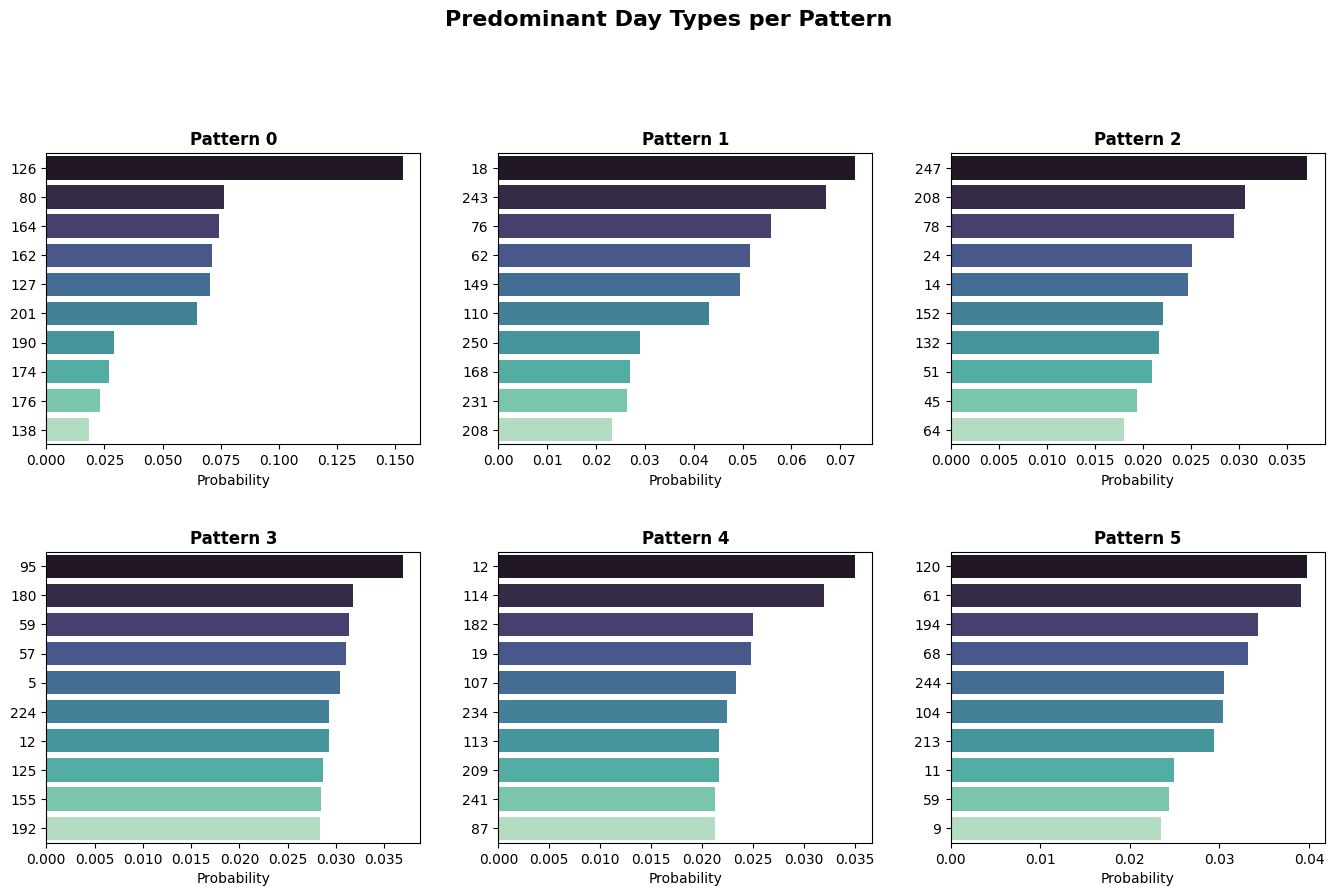

In [5]:
def get_top_terms_positive_probability(lda_model, corpus, dictionary, top_n=10):
    topic_term_dists = lda_model.get_topics()
    num_topics, vocab_size = topic_term_dists.shape
    vocab = [dictionary[i] for i in range(vocab_size)]
    rows = []
    for topic_idx in range(num_topics):
        topic_probs = topic_term_dists[topic_idx]
        top_indices = topic_probs.argsort()[::-1][:top_n]
        for rank, idx in enumerate(top_indices):
            rows.append({
                "topic": topic_idx,
                "rank": rank + 1,
                "profile": vocab[idx],
                "probability": topic_probs[idx],
            })
    return pd.DataFrame(rows)


def plot_top_terms_by_topic_grid(terms_df, save_path=None, top_n=10):
    num_topics = terms_df["topic"].nunique()
    n_cols = 3
    n_rows = (num_topics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 9))
    fig.suptitle("Predominant Day Types per Pattern", fontsize=16, fontweight="bold", y=1.02)
    axes = np.array(axes).flatten()
    for topic_idx in range(num_topics):
        ax = axes[topic_idx]
        topic_data = (terms_df[terms_df["topic"] == topic_idx]
                      .sort_values(by="probability", ascending=False).head(top_n))
        sns.barplot(x="probability", y="profile", data=topic_data, ax=ax,
                    palette="mako", hue="profile", legend=False)
        ax.set_title(f"Pattern {topic_idx}", fontsize=12, fontweight="semibold")
        ax.set_xlabel("Probability")
        ax.set_ylabel("")
    for i in range(num_topics, len(axes)):
        fig.delaxes(axes[i])
    plt.tight_layout(pad=3.0)
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {rel_path(Path(save_path))}")
    plt.show()


terms_topic = get_top_terms_positive_probability(lda_model, corpus_bow, dictionary, top_n=10)
plot_top_terms_by_topic_grid(
    terms_topic,
    save_path=str(RESULTS_FIG_DIR / "top_terms_grid.svg"),
)

# Save the top-10 predominant day-type profiles per topic (topic, profile)
# for downstream decoding (profile_decodification.ipynb).
TABLES_DIR = PROJECT_ROOT / "results/lda/tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
top10_path = TABLES_DIR / "lda_topics_top10.csv"
terms_topic[["topic", "profile"]].to_csv(top10_path, index=False)

## 5 · Assign topics per patient and merge with clinical data 

In [ ]:
topic_distributions = [
    lda_model.get_document_topics(bow, minimum_probability=0.0) for bow in corpus_bow
]

dist_list = []
for doc in topic_distributions:
    probs = [0.0] * NUM_TOPICS
    for tid, p in doc:
        probs[tid] = p
    dist_list.append(probs)

predominant = [max(doc, key=lambda x: x[1])[0] for doc in topic_distributions]
topic_cols = [f"topic_{i}" for i in range(NUM_TOPICS)]

result_df = pd.DataFrame({"id": df_profiles["user_id"], "predominant_topic": predominant})
result_df[topic_cols] = pd.DataFrame(dist_list, index=result_df.index)
result_df["id"] = pd.to_numeric(result_df["id"], errors="coerce").astype("Int64")

# Clinical data
bbdd = pd.read_excel(CLINICAL_XLSX)
bbdd.columns = bbdd.columns.str.strip()
bbdd = bbdd.rename(columns={"S_RECORD_id": "id", "ID": "id"})
bbdd["id"] = pd.to_numeric(bbdd["id"], errors="coerce").astype("Int64")

df_unido = pd.merge(result_df, bbdd, on="id", how="inner")
print("df_unido:", df_unido.shape)
df_unido[["id", "predominant_topic", "Evento PD"]].head()

df_unido: (175, 34)


,id,predominant_topic,Evento PD
0,11001,3,0.0
1,11003,3,1.0
2,11004,2,0.0
3,11005,1,0.0
4,11006,2,0.0


## 6 · Total topic probability mass by event (PD vs no-PD)

Saved: results/lda/figures/topic_probs_by_event.png


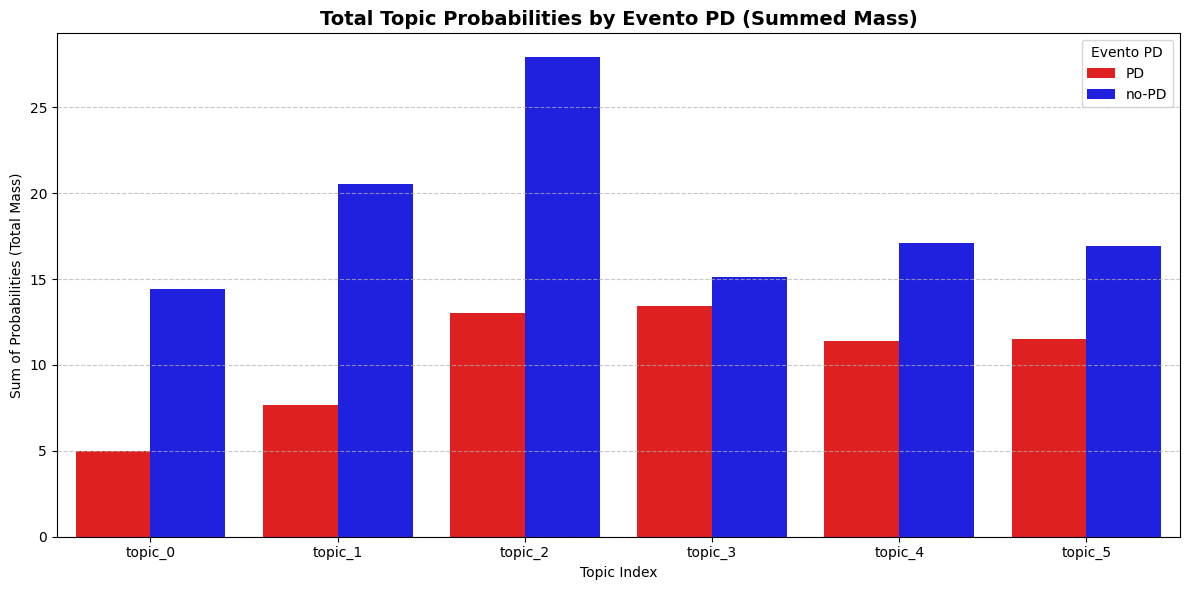

In [12]:
def plot_topic_probabilities_by_event(df, topic_cols, event_col="Evento PD", npatients=None,
                                      save_dir=None, filename="topic_probs_by_event.png"):
    df = df.copy()
    df["Event_label"] = df[event_col].astype(float).map({0.0: "no-PD", 1.0: "PD"})
    df_melted = df.melt(id_vars=["id", "Event_label"], value_vars=topic_cols,
                        var_name="Topic", value_name="Probability")
    grouped = df_melted.groupby(["Topic", "Event_label"])['Probability'].sum().reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(data=grouped, x="Topic", y="Probability", hue="Event_label",
                palette={"PD": "red", "no-PD": "blue"})
    title_text = f"Total Topic Probabilities by {event_col} (Summed Mass)"
    plt.title(title_text, fontsize=14, fontweight="bold")
    plt.ylabel("Sum of Probabilities (Total Mass)")
    plt.xlabel("Topic Index")
    plt.legend(title=event_col)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300)
        print(f"Saved: {rel_path(Path(save_dir) / filename)}")
    plt.show()


plot_topic_probabilities_by_event(
    df_unido, topic_cols=topic_cols, event_col="Evento PD", npatients=len(df_unido),
    save_dir=str(RESULTS_FIG_DIR),
)

## 7 · Predominant topic counts by event

Saved: results/lda/figures/topics_by_event.png


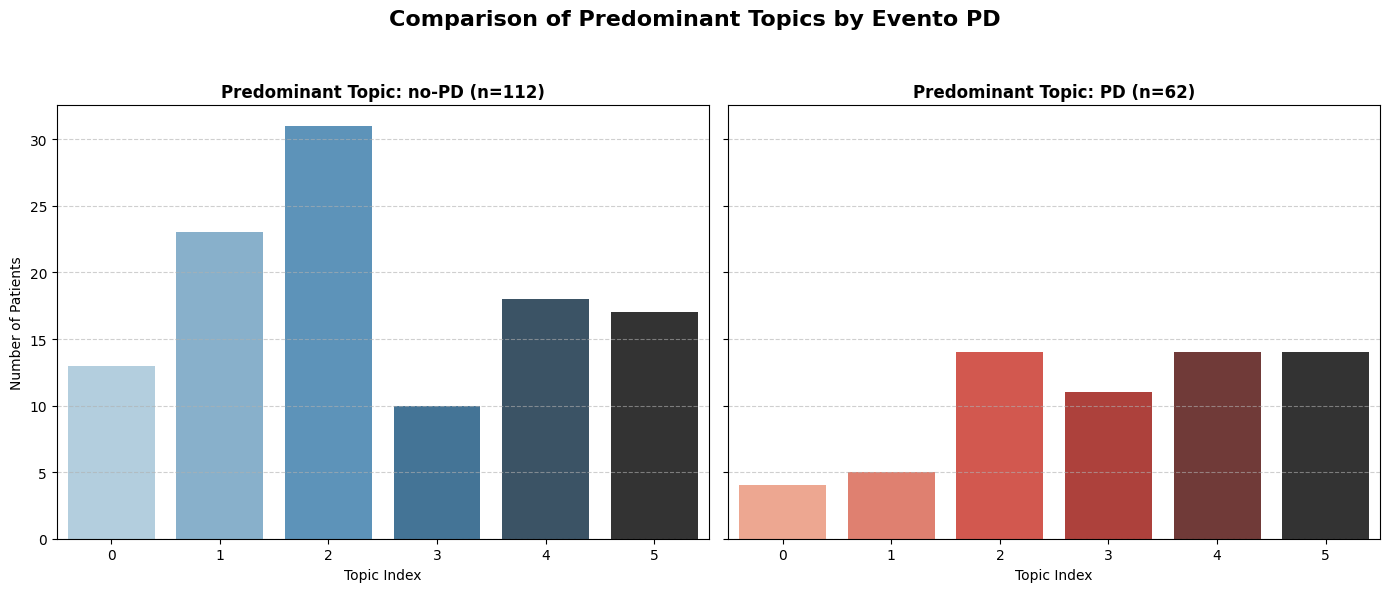

In [15]:
def plot_topics_by_event(df, event_col="Evento PD", n_topic=6, npatients=None,
                         save_dir=None, filename="topics_by_event.png"):
    df = df.copy()
    df[event_col] = df[event_col].astype(float)
    df_event_0 = df[df[event_col] == 0.0]
    df_event_1 = df[df[event_col] == 1.0]
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    sns.countplot(
        data=df_event_0, x="predominant_topic", hue="predominant_topic",
        ax=axs[0], palette="Blues_d", legend=False,
    )
    axs[0].set_title(f"Predominant Topic: no-PD (n={len(df_event_0)})", fontsize=12, fontweight="bold")
    axs[0].set_xlabel("Topic Index")
    axs[0].set_ylabel("Number of Patients")
    axs[0].grid(axis="y", linestyle="--", alpha=0.6)
    sns.countplot(
        data=df_event_1, x="predominant_topic", hue="predominant_topic",
        ax=axs[1], palette="Reds_d", legend=False,
    )
    axs[1].set_title(f"Predominant Topic: PD (n={len(df_event_1)})", fontsize=12, fontweight="bold")
    axs[1].set_xlabel("Topic Index")
    axs[1].set_ylabel("")
    axs[1].grid(axis="y", linestyle="--", alpha=0.6)
    title_main = f"Comparison of Predominant Topics by {event_col}"
   
    fig.suptitle(title_main, fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches="tight")
        print(f"Saved: {rel_path(Path(save_dir) / filename)}")
    plt.show()


plot_topics_by_event(
    df_unido, event_col="Evento PD", n_topic=NUM_TOPICS, npatients=len(df_unido),
    save_dir=str(RESULTS_FIG_DIR),
)

## 8 · Average topic distribution by event

Saved: results/lda/figures/avg_topic_distribution_by_event.png


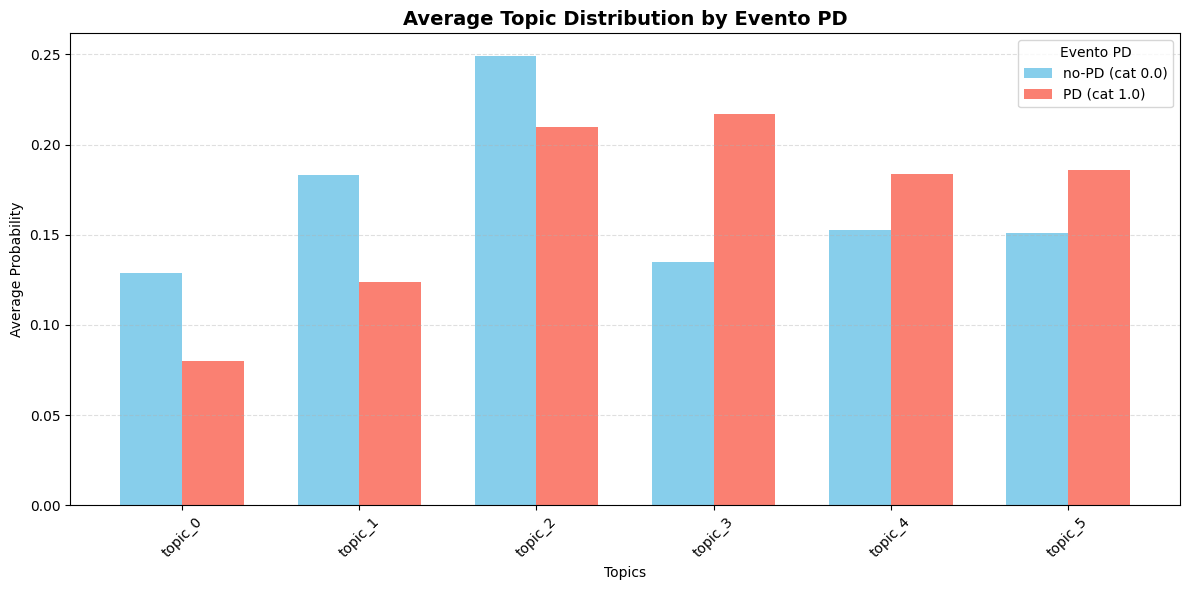

In [14]:
def plot_avg_topic_distribution_by_event(df, topic_columns, group_col="Evento PD", n_topic=6,
                                         npatients=None, save_dir=None,
                                         filename="avg_topic_distribution.png", enriched=False):
    df_avg_topics = df.groupby(group_col)[topic_columns].mean()
    categories = sorted(df_avg_topics.index.unique())
    x_pos = np.arange(len(topic_columns))
    plt.figure(figsize=(12, 6))
    bar_width = 0.35
    colors = ["skyblue", "salmon", "lightgreen", "orange"]
    for i, cat in enumerate(categories):
        offset = -bar_width / 2 if i == 0 else bar_width / 2
        label_text = f"no-PD (cat {cat})" if cat == 0 else f"PD (cat {cat})"
        if cat not in [0, 1, 0.0, 1.0]:
            label_text = f"Group: {cat}"
        plt.bar(x_pos + offset, df_avg_topics.loc[cat], width=bar_width,
                label=label_text, color=colors[i % len(colors)])
    plt.xlabel("Topics")
    plt.ylabel("Average Probability")
    title_base = f"Average Topic Distribution by {group_col}"
    if enriched:
        title_base += f" ({n_topic} topics enriched)"
  
    plt.title(title_base, fontsize=14, fontweight="bold")
    plt.xticks(x_pos, topic_columns, rotation=45)
    plt.legend(title=group_col)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300)
        print(f"Saved: {rel_path(Path(save_dir) / filename)}")
    plt.show()


plot_avg_topic_distribution_by_event(
    df_unido, topic_columns=topic_cols, group_col="Evento PD", n_topic=NUM_TOPICS,
    npatients=len(df_unido), enriched=False, save_dir=str(RESULTS_FIG_DIR),
    filename="avg_topic_distribution_by_event.png",
)